# Jupyter Notebook
## Lecture 5 - Assessing Coefficient Accuracy

In the today's lectures, we are starting focused on simple linear regression, that is, fitting models of the form 

$$
Y =  \beta_0 +  \beta_1 X_1 + \varepsilon
$$

In this lab, we will use two different tools for linear regression. 
- [Scikit learn](https://scikit-learn.org/stable/index.html) is arguably the most used tool for machine learning in python 
- [Statsmodels](https://www.statsmodels.org) provides many of the statisitcial tests we've been learning in class

In [7]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns

# Importing the Linear Regression we learned last time from sklearn
from sklearn.linear_model import LinearRegression



# Simulating data 
Ok, let's run an example like was shown in class where we see the distribution of possible values. 

In [2]:
# Here's code that decides on my function 
def myFunc(x, b0=2, b1=5): 
    return b0 + b1*x


# Here's a command that generates 100 random data points from f(x) + epsilon
def makeData(n = 100):
    X = np.random.uniform(-2,2,n)
    y = myFunc(X) + np.random.normal(size = n)
    return X,y

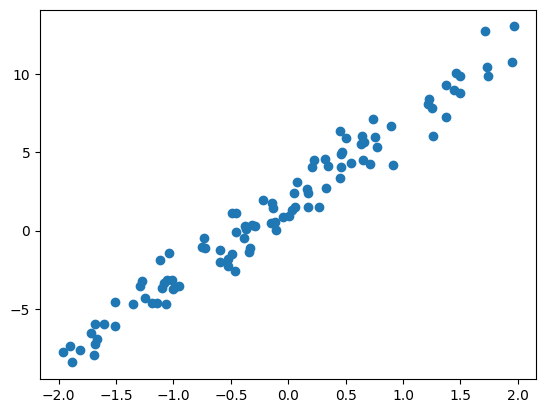

In [3]:
# Everytime you run this cell, you get slightly different data

X,y = makeData()

plt.scatter(X,y)

In [6]:
# Which means that every time you run this cell, you get a slightly different choice of coefficients
# for the model learned

X,y = makeData()
X = X.reshape([len(X),1])
y = y.reshape([len(y),1])
reg = LinearRegression()
reg.fit(X,y)
print( 'y = '+ str(round(reg.intercept_[0],4)) +' + ' + str(round(reg.coef_[0,0],4)) +  " * x_1"  )


y = 2.0956 + 5.0452 * x_1


&#9989; **<font color=red>Q:</font>** 
If we assume that our data is coming from the setting 

$$
Y = f(X) + \varepsilon
$$

what is $\mathrm{Var}(\varepsilon)$?

###1###

In [8]:
# So now, lets just train our linear model lots of times, and collect the resulting coefficients

beta0_list = []
beta1_list = []
for i in range(100):
    X,y = makeData()
    X = X.reshape([len(X),1])
    y = y.reshape([len(y),1])
    reg = LinearRegression()
    reg.fit(X,y)
    beta1_list.append(reg.coef_[0,0])
    beta0_list.append(reg.intercept_[0])

print(beta1_list)

[5.037600539325737, 5.016319439361948, 5.030980559257523, 4.957304160531449, 5.0109695974717665, 4.975651434422138, 4.961935714175939, 5.0310609864152696, 5.037459852771333, 4.99256072787094, 5.0296270439163875, 5.154263509931343, 4.983783494226598, 4.967686721030571, 5.033139891384631, 5.0578856408222, 4.995952759078559, 5.083467096748975, 4.9418172757566525, 4.962041117758516, 5.116729053097361, 4.9887431125591934, 5.05175716965239, 5.029460235564073, 5.028271237279098, 5.059602029534283, 5.104470945459705, 5.000814196136921, 4.8756147465899335, 4.905946014829756, 4.909880787258587, 4.915990042440197, 5.007557325392349, 5.017696603962578, 5.014093107781346, 4.844724828179638, 5.108501101755616, 4.994296622364146, 5.131479947929114, 5.076327526131845, 4.898377193266452, 4.940318387409837, 4.958982197688438, 5.018453671066253, 4.927910542626688, 4.942087924630777, 5.145530465727162, 5.120679179841388, 4.987001746454476, 4.8983571120609675, 4.965676404417789, 4.935766258463192, 4.832986

&#9989; **<font color=red>Q:</font>** 
Make a histogram of `beta0_list`.  


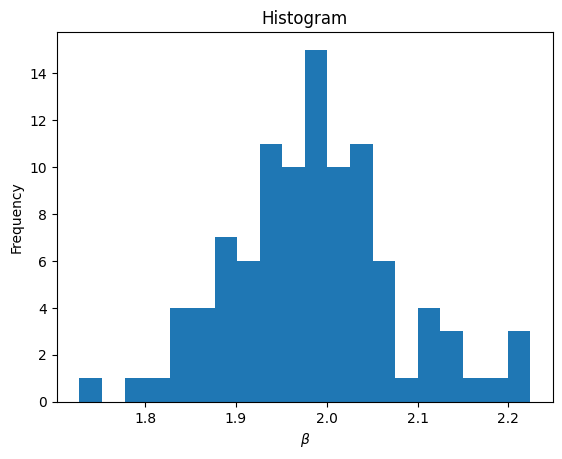

In [16]:
plt.figure()
plt.hist(beta0_list, bins=20)
plt.xlabel(r'$\beta$')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

&#9989; **<font color=red>Q:</font>** 
Make a histogram of `beta1_list`.  

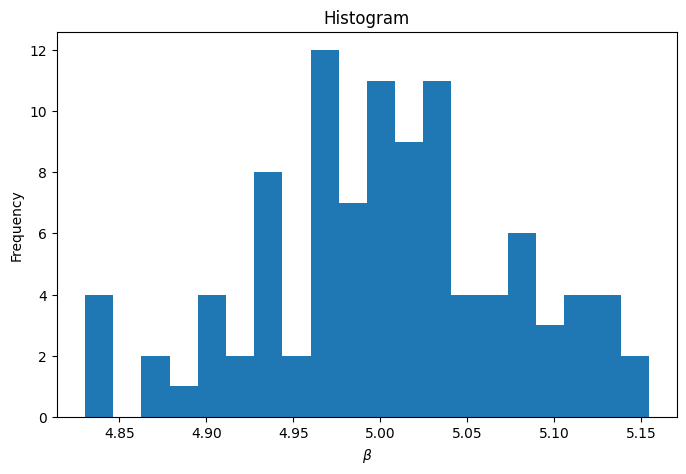

In [17]:
plt.figure(figsize=(8,5))
plt.hist(beta1_list, bins=20)
plt.xlabel(r'$\beta$')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

&#9989; **<font color=red>Q:</font>**  
- What is the mean of each list?

In [18]:
np.mean(beta0_list), np.mean(beta1_list)

(1.9861613492339762, 5.003609015912751)

&#9989; **<font color=red>Q:</font>**  
- How does these means compare to the acutal line we used to generate the data?


In [19]:
# The mean of beta0_list is only about 0.014 below the true intercept
# The mean of beta1_list is only about 0.004 above the true slope

&#9989; **<font color=red>Q:</font>**  
- What is the standard deviation of each list? 

In [20]:
np.std(beta0_list), np.std(beta1_list)

(0.09258119017171422, 0.07269801821389306)

## Variance in estimation

Now let's figure out the variance of the linear regression estimates. First off, we know that $\sigma^2 = \mathrm{Var}(\varepsilon) = 1$, but let's pretend we didn't make up our own fake data. 


In [21]:
# Start with a single linear regression model
reg = LinearRegression()
reg.fit(X,y)
print( 'y = '+ str(round(reg.intercept_[0],4)) +' + ' + str(round(reg.coef_[0,0],4)) +  " * x_1"  )

y = 1.8439 + 5.0052 * x_1



We can estimate $\sigma$ using residual standard error:

$$
\mathrm{RSE} = \sqrt{\mathrm{RSS}/(n-2)}
$$

In [22]:
predicted = reg.predict(X)
residuals = y - predicted

RSS = np.sum(residuals**2)
RSE = np.sqrt(RSS/(len(y)-2))

Then the following code can compute the standard error of each coefficient

In [23]:
# We're estimating sigma^2 by RSE^2
sigma_sq = RSE**2

# We have n = 100 data points
n = 100

# We can calculate the standard error of beta_0 and beta_1 using the formulas we learned in class
x_bar = np.mean(X)
denom = np.sum((X - x_bar)**2)
beta0_var = sigma_sq * (1/n + x_bar**2/denom)
SE_beta0 = np.sqrt(beta0_var)
print(f"Standard error of beta0: {SE_beta0}")


beta1_var = sigma_sq/denom
SE_beta1 = np.sqrt(beta1_var)
print(f"Standard error of beta1: {SE_beta1}")


Standard error of beta0: 0.08037047201469424
Standard error of beta1: 0.07617015512532488


While we had to work a bit to get this to write out the standard errors, we can use the `statsmodels` library instead of `sklearn` to get these values directly.

In [24]:
import statsmodels.formula.api as smf
mydata = pd.DataFrame({'X':X.flatten(), 'y':y.flatten()})
linreg_smf = smf.ols('y ~ X', data = mydata).fit()
linreg_smf.summary()
linreg_smf.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.8439,0.080,22.942,0.000,1.684,2.003
X,5.0052,0.076,65.710,0.000,4.854,5.156


&#9989; **<font color=red>Q:</font>** What is $SE(\hat \beta_0)$ and $SE(\hat \beta_1)$? Are they the same as what we calculated above?

In [25]:
# 0.08037 and 0.07617. They are the same

![Stop Icon](https://upload.wikimedia.org/wikipedia/commons/thumb/1/1e/Vienna_Convention_road_sign_B2a.svg/180px-Vienna_Convention_road_sign_B2a.svg.png)

Great, you got to here! Hang out for a bit, there's more lecture before we go on to the next portion. 

------
## 2. Assessing Coefficient Estimate Accuracy
### The Dataset

We will be using the `Diabetes` data set again, which you looked into from the last class. In case you've forgotten, there is information about the data set [in the documentation](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).

In [26]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes(as_frame=True)
diabetes_df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
diabetes_df['target'] = pd.Series(diabetes.target)

diabetes_df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0



Like last time, we're now going to fit to a simple linear regression to the models
$$
\texttt{target} = \beta_0 + \beta_1 \cdot\texttt{s1}
$$
and 
$$
\texttt{target} = \beta_0 + \beta_1 \cdot\texttt{s5}
$$
where the variables are 
- $\texttt{s1}$: tc, total serum cholesterol

- $\texttt{s5}$: ltg, possibly log of serum triglycerides level. 

Let's start by looking at using `s5` to predict `target`.




Just for completeness, here's our code to do linear regression from last time using `sklearn`. 

In [27]:
from sklearn.linear_model import LinearRegression


# sklearn actually likes being handed numpy arrays more than 
# pandas dataframes, so we'll extract the bits we want and just pass it that. 
X = diabetes_df['s5'].values
X = X.reshape([len(X),1])
y = diabetes_df['target'].values
y = y.reshape([len(y),1])

# This code works by first creating an instance of 
# the linear regression class
reg = LinearRegression()
# Then we pass in the data we want it to use to fit.
reg.fit(X,y)

# and we can get the coefficients we want out of the model from the following code.

print(reg.coef_)
print(reg.intercept_)

# I can do some fancy printing if I really want to
lineString = str(round(reg.coef_[0,0],4)) +  "x_1 + " +  str(round(reg.intercept_[0],4))
print( 'y = ', lineString)

[[916.13737455]]
[152.13348416]
y =  916.1374x_1 + 152.1335


However today we're interested in statistical tests so we'll be using the `statsmodel` package. It has more options for statistical tests when available, however it has fewer models available which is why we will using a bit of both in this class. 

In [28]:
import statsmodels.formula.api as smf


**<font color=red>Instructor note:</font>** There is a difference in here where the book uses 
```python
import statsmodels.api as sm
model = sm.OLS(y, X)
```
which has some weird stuff with needing to include an intercept column and such. On homework problems and the like you can use this code or follow the book, either is acceptable. 

In [29]:
# Notice that the code is intentially written to look
# more like R than like python, but it still works!
# Double check..... the coefficients here should be
# about the same as those found by scikit-learn
est = smf.ols('target ~ s5', diabetes_df).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,152.1335,3.027,50.263,0.000,146.185,158.082
s5,916.1374,63.634,14.397,0.000,791.072,1041.202


&#9989; **<font color=red>Q:</font>** What is $SE(\hat \beta_0)$ and $SE(\hat \beta_1)$?

In [30]:
# 3.027 and 63.634

&#9989; **<font color=red>Q:</font>** If we instead use `s1` to predict the target, are $SE(\hat \beta_0)$ and $SE(\hat \beta_1)$ higher or lower than what you found for the `s5` prediction? Is this reasonable? 

In [33]:
model_s5 = smf.ols('target s5', data=diabetes_df).fit()
se_s5 = model_s5.bse

model_s1 = smf.ols('target s1', data=diabetes_df).fit()
se_s1 = model_s1.bse

print("Standard errors using s5:")
print(se_s5)

print("\nStandard errors using s1:")
print(se_s1)

SyntaxError: invalid syntax (<unknown>, line 1)

##YOUR ANSWER HERE##


&#9989; **<font color=red>Q:</font>** Try plotting your predictions as a function of $s_5$ alongside scatter plots of the data for comparison.

In [29]:
##YOUR CODE HERE## 



&#9989; **<font color=red>Q:</font>** Try plotting your predictions as a function of $s_1$ alongside scatter plots of the data for comparison.

In [30]:
##YOUR CODE HERE## 


# Higher error for the slope makes sense because we're 
# looking at less linear data. 

&#9989; **<font color=red>Q:</font>** What are the confidence intervals for  $\hat \beta_1$ in the two cases (the prediction using `s1` and the prediction using `s5`)? Which is wider and why? 

*Hint: Check out the `est.conf_int` command or you can find this in the summary tables you've been using earlier.*

Your answer here. 

In [31]:
## Put your code here


###ANSWER:###  The confidence interval for $\hat{\beta}_1$ is wider when using $\texttt{s1}$ because the $\texttt{s1}$ model has larger residual variance, leading to a larger standard error of the slope estimate compared to the $\texttt{s5}$ model.

&#9989; **<font color=red>Q:</font>** What is the conclusion of the hypothesis test

$$H_0: \text{ There is no relationship between $X$ and $Y$}$$

$$H_a: \text{ There is some relationship between $X$ and $Y$}$$

at a confidence level of $\alpha = 0.05$?

In [32]:
#Your code here


In [33]:
##YOUR ANSWER HERE## 
# answer is in the table given as the p-value. In this case, 
# it's so small it's basically 0 in all cases 
# This means we reject the null hypothesis
est.summary().tables[1]


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,152.1335,3.027,50.263,0.000,146.185,158.082
s5,916.1374,63.634,14.397,0.000,791.072,1041.202


Oh hey look, there's another table with information stored by the statsmodel class. 

In [52]:
est.summary().tables[0]

Dep. Variable:,target,R-squared:,0.320
Model:,OLS,Adj. R-squared:,0.319
Method:,Least Squares,F-statistic:,207.3
Date:,"Sat, 07 Sep 2024",Prob (F-statistic):,8.83e-39
Time:,15:13:56,Log-Likelihood:,-2461.9
No. Observations:,442,AIC:,4928.
Df Residuals:,440,BIC:,4936.
Df Model:,1,,
Covariance Type:,nonrobust,,


&#9989; **<font color=red>Q:</font>** What is $R^2$ for the two models?

In [34]:
##YOUR CODE AND ANSWER HERE##




-----
### Congratulations, we're done!

Initially created by Dr. Liz Munch, modified by Dr.Bao and Dr. Khasawneh, Michigan State University
<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [48]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 
from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


ModuleNotFoundError: No module named 'jupyterinstruct'